# Information Visualization I 
## School of Information, University of Michigan

## Week 3: 
- Perception / Cognition

## Assignment Overview
### This assignment's objectives include:

- Review, refect, and apply the concepts of the perception pipeline. Justify how different encodings impact the effectiveness of a visualization depending on the human perception process.

!["Drawing"](/voc/data/preattentive_resized.png)

<p style="text-align: center;"> Preattentive Processing </p>

- Recreate visualizations and propose new and alternative visualizations using [Altair](https://altair-viz.github.io/) 

### The total score of this assignment will be 100 points consisting of:
- Case study reflection: America's Favorite 'Star Wars' Movies (And Least Favorite Characters) (25 points)
- Altair programming exercise (75 points)

### Resources:
- Article by [FiveThirtyEight](https://fivethirtyeight.com) available  [online](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) (Hickey, 2014)  
- Datasets from FiveThirtyEight, we have downloaded a subset of this data in the folder [./assets](assets)
    - The original dataset can be found at [FiveThirtyEight Star Wars Survey](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)
    

### Important notes:
1) There will be a couple of places where the numbers you get when you select rows may be a little different than 538, but the percents should still work (e.g., 828 instead of 834). You'll see this in our examples. If you can somehow get the data to match exactly, that's great too.

2) A lot of this assignment will be based on building "compound" charts. Using the wrong strategy will mean that you are spending a lot of time "cleaning up" charts. We strongly suggest reading through (and understanding) the Altair documentation [on this](https://altair-viz.github.io/user_guide/compound_charts.html).

3) Grading for this assignment is entirely done by a human grader. They will be running tests on the functions we ask you to create. This means there is no autograding (submitting through the autograder will result in an error). You are expected to test and validate your own code. 

4) Keep your notebooks clean and readable. If your code is highly messy or inefficient you will get a deduction.

5) Follow the instructions for submission on Coursera. You will be providing us a generated link to a read-only version of your notebook and a PDF. When turning in your PDF, please use the File -> Print -> Save as PDF option ***from your browser***. Do ***not*** use the File->Download as->PDF option. Complete instructions for this are under Resources in the Coursera page for this class. If you're having trouble with printing, take a look at [this video](https://youtu.be/PiO-K7AoWjk).

## Part 1. Perception and Cognition (25 points)
Read the article ["America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters),"](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) and answer the following questions:


### 1.1 List the different data types in the following visualizations and their encodings (10 points)
Look at the following visualizations. For each, list the variable, their type, and the encoding used. 

!["How rate visualization"](/voc/data/how_rate_resized.png)
!["Have seen visualization"](/voc/data/have_seen_resized.png)

Use the following table for each variable (indicate which vis each came from):
* variable name, variable type (e.g., ordinal, nominal, etc.), variable encoding (e.g., color, x-position, etc.)

For example, if you [look at this visualization](https://altair-viz.github.io/gallery/scatter_tooltips.html) one row in our table below would be: Horsepower, quantitative, x-position.

_1.1 Answer_

*Use as many rows as you need*

How People Rate the 'Star Wars' Movies

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Movie Rating | Quantitative | X-Position |
|  Movie Title | Nominal | Y-Position |
|  Rank Category | Ordinal | Color |

Which 'Star Wars' Movies Have You Seen?

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Percentage of Respondents Who Have Seen Movie | Quantitative | X-Position |
|  Movie Title | Nominal | Y-Position |



### 1.2 A Pie Chart Version (15 points)


!["Drawing"](/voc/data/have_seen_resized.png)

Your colleague is arguing that the chart above could be made more *effective* by using one or more pie charts. In what situations are they right? In what situations would they be wrong? If it helps makes your case, feel free to create a picture (hand drawn is fine) and load it into the notebook.

**When they would be right:**

My colleague would be right to use a pie chart if the question was asking about a category which sum to 100%. For example, "Of all Star Wars Movies, what is your favorite?". In the example above, each movie in the chart is individually on a scale of 0-100%. Changing the chart so that it is a faceted pie chart (6 different pie charts for each movie) would correctly visualize the data since each movie's total percentage would equal 100% ("seen" vs. "not seen").

**When they would be wrong (this case):**

The percentages don't sum to 100% (in the case above, all percentages sum to 466), and the categories aren't mutually exclusive (in the case above, a respondent could see both 'A New Hope' and 'The Empire Strikes Back').

## Part 2. Altair programming exercise (75 points)
We have provided you with some code and parts of the article [America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/). This article is based on the dataset:

1. [StarWars](data/StarWars.csv) Created by FiveThirtyEight based on a survey ran through SurveyMonkey Audience, surveying 1,186 respondents from June 3 to 6 2014. Available [online] (https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

To earn points for this assignment, you must:

- Recreate the visualizations in the article (replace the images in the article with a code cell that creates a visualization). We provide one example. Each visualization is worth 10 points (40 points/ 10 each x 4 total ).

    - _Partial credit can be granted for each visualization (up to 5 points) if you provide the grammar of graphics description of the visualization without a functional Altair implementation_


- Propose two variants (a "good one" and a "bad one") for a new visualization for the article. You'll be asked to justify why one is better than the other. We are specifically interested in your explanation of why the "good one" is more *effective* based on principles of perception/cognition. (35 points/ 20 points for the plots + 15 for justification)




In [1]:
import pandas as pd
import altair as alt
import numpy as np
import math
from mads.lib.path import assets

In [2]:
# enable correct rendering
alt.renderers.enable('mimetype')

RendererRegistry.enable('mimetype')

In [3]:
# uses intermediate json files to speed things up
alt.data_transformers.enable('json')

DataTransformerRegistry.enable('json')

In [4]:
def loadStarwarsData(filename='StarWars.csv'):
    
    # input: filename to original dataset (default StarWars.csv)
    # output: cleaned up dataframe with columns appropriately renamed
    
    filename = assets.find(filename)
    sw = pd.read_csv(filename, encoding='latin1')

    # Some format is needed for the survey dataframe, we provide the formatted dataset in a dataframe 
    sw = sw.rename(columns={'Have you seen any of the 6 films in the Star Wars franchise?':'seen_any_movie',
                            'Do you consider yourself to be a fan of the Star Wars film franchise?': 'fan',
                            'Which of the following Star Wars films have you seen? Please select all that apply.' : 'seen_EI',
                            'Unnamed: 4' : 'seen_EII',
                            'Unnamed: 5' : 'seen_EIII',
                            'Unnamed: 6' : 'seen_EIV',
                            'Unnamed: 7' : 'seen_EV',
                            'Unnamed: 8' : 'seen_EVI',
                            'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.' : 'rank_EI',
                            'Unnamed: 10' : 'rank_EII',
                            'Unnamed: 11' : 'rank_EIII',
                            'Unnamed: 12' : 'rank_EIV',
                            'Unnamed: 13' : 'rank_EV',
                            'Unnamed: 14' : 'rank_EVI',
                            'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.' : 'Han Solo',
                            'Unnamed: 16' : 'Luke Skywalker',
                            'Unnamed: 17' : 'Princess Leia Organa',
                            'Unnamed: 18' : 'Anakin Skywalker',
                            'Unnamed: 19' : 'Obi Wan Kenobi',
                            'Unnamed: 20' : 'Emperor Palpatine',
                            'Unnamed: 21' : 'Darth Vader',
                            'Unnamed: 22' : 'Lando Calrissian',
                            'Unnamed: 23' : 'Boba Fett',
                            'Unnamed: 24' : 'C-3P0',
                            'Unnamed: 25' : 'R2 D2',
                            'Unnamed: 26' : 'Jar Jar Binks',
                            'Unnamed: 27' : 'Padme Amidala',
                            'Unnamed: 28' : 'Yoda',
                           })
    sw = sw.drop([0])
    return(sw)

sw = loadStarwarsData()

In [5]:
# take a peak to look at the data
sw.sample(5)

,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,...,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
1168,3.288410e+09,Yes,No,Star Wars: Episode I The Phantom Menace,NaN,NaN,NaN,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,Greedo,Yes,No,No,Female,30-44,NaN,Graduate degree,East North Central
504,3.290395e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,Han,No,NaN,Yes,Female,30-44,"$50,000 - $99,999",Bachelor degree,East South Central
25,3.292465e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,1,...,Very favorably,Han,No,NaN,No,Male,18-29,NaN,NaN,East North Central
1105,3.288514e+09,Yes,No,NaN,NaN,NaN,NaN,Star Wars: Episode V The Empire Strikes Back,NaN,4,...,Neither favorably nor unfavorably (neutral),I don't understand this question,No,NaN,No,Female,18-29,"$50,000 - $99,999",Graduate degree,East South Central
18,3.292573e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,Star Wars: Episode VI Return of the Jedi,1,...,Very favorably,Greedo,No,NaN,No,Male,18-29,NaN,Some college or Associate degree,Middle Atlantic


# America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)

_Original article available at [FiveThirtyEight](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/)_

By [Walt Hickey](https://fivethirtyeight.com/contributors/walt-hickey/)

Filed under [Movies](https://fivethirtyeight.com/tag/movies/)

Get the data on [GitHub](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

This week, I caught a sneak peek [of the X-Wing fighter](http://www.wired.com/2014/07/star-wars-episode-vii-x-wing/) from the new “Star Wars” films in production. The forthcoming movies — and the middling response to the most recent trilogy — provide a perfect excuse to examine some questions I’ve long wanted answers to: How many people are “Star Wars” fans? Does the rest of America realize that “The Empire Strikes Back” is clearly the best of the bunch? Which characters are most well-liked and most hated? And who shot first, Han Solo or Greedo?

We ran a poll through [SurveyMonkey Audience](https://www.surveymonkey.com/mp/audience/), surveying 1,186 respondents from June 3 to 6 (the [data](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey) is available [on GitHub](https://github.com/fivethirtyeight/data)). Seventy-nine percent of those respondents said they had watched at least one of the “Star Wars” films. This question, incidentally, had a substantial difference by gender: 85 percent of men have seen at least one “Star Wars” film compared to 72 percent of women. Of people who have seen a film, men were also more likely to consider themselves a fan of the franchise: 72 percent of men compared to 60 percent of women.

We then asked respondents which of the films they had seen. With 835 people responding, here’s the probability that someone has seen a given “Star Wars” film given that they have seen any Star Wars film:

!["Sol1"](/voc/data/have_seen_resized.png)

In [6]:
# We're going to fix the labels a bit so will create a mapping to the full names
# and have the full sort order
def genEpisodeNamesDF():
    # create the various mapping and order lists/dictionaries
    # return: list of episodes (in order), episode->name map, list of episode names (in order)
    episodes = ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']
    names = {
        'EI' : 'The Phantom Menace', 'EII' : 'Attack of the Clones', 'EIII' : 'Revenge of the Sith', 
        'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI' : 'The Return of the Jedi'
    }

    # we're also going to use this order to sort, so names_l will now have our sort order
    return episodes, names, [names[ep] for ep in episodes]

episodes, namesDict, namesList = genEpisodeNamesDF()

In [7]:
# let's inspect what we've generated. These will be useful to you below
print("abbreviated list (sorted):\n  ",episodes)
print("\nmapping between abberviated names and full titles:\n  ",namesDict)
print("\nfull titles, sorted:\n  ",namesList)


abbreviated list (sorted):
   ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']

mapping between abberviated names and full titles:
   {'EI': 'The Phantom Menace', 'EII': 'Attack of the Clones', 'EIII': 'Revenge of the Sith', 'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI': 'The Return of the Jedi'}

full titles, sorted:
   ['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith', 'A New Hope', 'The Empire Strikes Back', 'The Return of the Jedi']


In [8]:
# let's do some data pre-processing... recall that sw (star wars) has everything

def getSeenAtLeastOneDF(indf, eps):
    # input: indf the data file as formatted above
    # input: eps a list of episodes (movies)

    # returns a subset of the dataset
    
    # We want to only use those people who have seen at least one movie, let's get the people, toss NAs
    # and get the total count

    # find people who have at least on of the columns (seen_*) not NaN
    salo = indf.dropna(subset=['seen_' + ep for ep in eps],how='all')
    
    return(salo)

In [9]:
seenAtLeastOneDF = getSeenAtLeastOneDF(sw, episodes)
print("total who have seen at least one: ", len(seenAtLeastOneDF),"\nSample:")
display(seenAtLeastOneDF.sample(5))

total who have seen at least one:  835 
Sample:


,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,...,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
205,3.290992e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,NaN,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Very favorably,Han,No,NaN,Yes,Female,18-29,"$25,000 - $49,999",Bachelor degree,East North Central
782,3.289722e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,1,...,Neither favorably nor unfavorably (neutral),I don't understand this question,Yes,Yes,No,Male,> 60,"$50,000 - $99,999",Bachelor degree,West South Central
1098,3.288524e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Han,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Graduate degree,Pacific
565,3.290217e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,Han,No,NaN,No,Female,18-29,"$0 - $24,999",Bachelor degree,New England
1068,3.288578e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Very favorably,I don't understand this question,No,NaN,Yes,Female,45-60,"$150,000+",Graduate degree,West South Central


In [10]:
# for each movie, we're going to calculate the percents and generate a new data frame

def genSeenPercentDf(inpf, names=namesDict, names_l=namesList):
    # input: inpf - an input frame of the form output by getSeenAtLeastOneDF()
    # input: names - a dictionary of abbreviations to names
    # input: names_l - a list of all the movies in series order
    
    total = len(inpf)
    percs = []

    # loop over each column and calculate the number of people who have seen the movie
    # specifically, filter out the people who are *NaN* for a specific episode (e.g., ep_EII), count them
    # and divide by the percent
    for seen_ep in ['seen_' + ep for ep in episodes]:
        perc = len(inpf[~ pd.isna(inpf[seen_ep])]) / total
        percs.append(perc)

    # at this point percs is holding our percentages

    # now we're going use a trick to make tuples--pairing names with percents--using "zip" and then make a dataframe
    tuples = list(zip([names[ep] for ep in episodes],percs))
    seen_per_df = pd.DataFrame(tuples, columns = ['Name', 'Percentage'])
    return(seen_per_df)

In [11]:
seenPerMovieDF = genSeenPercentDf(seenAtLeastOneDF)

In [12]:
# let's see what's inside
seenPerMovieDF

,Name,Percentage
0,The Phantom Menace,0.805988
1,Attack of the Clones,0.683832
2,Revenge of the Sith,0.658683
3,A New Hope,0.726946
4,The Empire Strikes Back,0.907784
5,The Return of the Jedi,0.883832


In [13]:
def genPercentVis(indf, names_l=namesList):
    # input: indf, the dataframe as seen_per_df
    # input: names_l - a list of all the movies in series order (default namesList)
    # output: simple altair bar chart
    
    # ok, time to make the chart... let's make a bar chart (use mark_bar)
    bars = alt.Chart(indf).mark_bar(size=20).encode(
        # encode x as the percent, and hide the axis
        x=alt.X(
            'Percentage',
            axis=None),
        y=alt.Y(
            # encode y using the name, use the movie name to label the axis, sort using the names_l
            'Name:N',
             axis=alt.Axis(tickCount=5, title=''),
             # we give the sorting order to avoid alphabetical order
             sort=names_l
        )
    )

    # at this point we don't really have a great plot (it's missing the annotations, titles, etc.)
    return(bars)

seenPerMovieVis = genPercentVis(seenPerMovieDF)

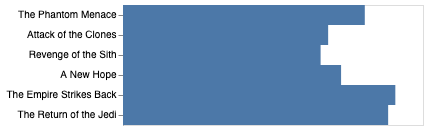

In [14]:
# display it
seenPerMovieVis

In [15]:
def augmentPercentVis(base):
    # input: base (the base vis, i.e., bars as above)
    # we're going to overlay the text with the percentages, so let's make another visualization
    # that's just text labels


    text = base.mark_text(
        align='left',
        baseline='middle',
        dx=3  # Nudges text to right so it doesn't appear on top of the bar
    ).encode(
        # we'll use the percentage as the text
        text=alt.Text('Percentage:Q',format='.0%')
    )

    # finally, we're going to combine the bars and the text and do some styling
    seen_movies = (text + base).configure_mark(
        # we don't love the blue
        color='#008fd5'
    ).configure_view(
        # we don't want a stroke around the bars
        strokeWidth=0
    ).configure_scale(
        # add some padding
        bandPaddingInner=0.2
    ).properties(
        # set the dimensions of the visualization
        width=500,
        height=180
    ).properties(
        # add a title
        title="Which 'Star Wars' Movies Have you Seen?"
    )

    return(seen_movies)

# note that we are NOT formatting this in the Five Thirty Eight Style yet... we'll leave that to you to figure out

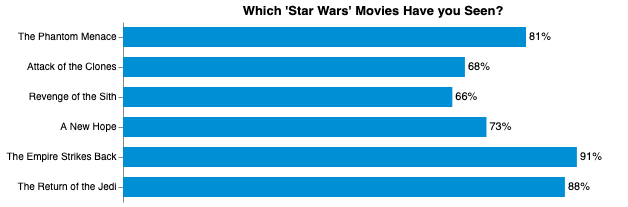

In [16]:
# let's see it
augmentPercentVis(seenPerMovieVis)

So we can see that “Star Wars: Episode V — The Empire Strikes Back” is the film seen by the most number of people, followed by “Star Wars: Episode VI — Return of the Jedi.” Appallingly, more people reported seeing “Star Wars: Episode I — The Phantom Menace” than the original “Star Wars” (renamed “Star Wars: Episode IV — A New Hope”).

So, which movie is the best? We asked the subset of 471 respondents who indicated they have seen every “Star Wars” film to rank them from best to worst. From that question, we calculated the share of respondents who rated each film as their favorite.

!["Sol1"](/voc/data/best_movie_article_resized.png)


** Homework note: Click [here](/voc/data/best_movie.png) to see a version of this plot generated in Altair.

### 2.1 What's the best 'Star Wars' movie? Recreate the above image using altair (10 Points)

Recreate the image above using Altair. Match the "538" style as best you can (hint: look at the altair lab at the start of the semester). We expect you to *at least* match the [our version](best_movie.png) of the chart that was created in Altair.

In [17]:
# Recreate this image using Altair
# match the "538 style" as best you can (hint: look at the altair lab at the start of the semester)

def genBestVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above

    seen_cols = ['seen_EI', 'seen_EII', 'seen_EIII', 'seen_EIV', 'seen_EV', 'seen_EVI']
    rank_cols = ['rank_EI', 'rank_EII', 'rank_EIII', 'rank_EIV', 'rank_EV', 'rank_EVI']
    
    # create mask to filter dataset so that it only shows respondents that have seen all movies
    seen_all_movies_mask = inpf[seen_cols].notna().all(axis = 1)
    seen_all_movies_df = inpf[seen_all_movies_mask].copy()

    # convert all rank_cols values to integers
    seen_all_movies_df[rank_cols] = seen_all_movies_df[rank_cols].astype('Int64')

    # find each respondent's best movie (ranked as 1)
    best_movie = seen_all_movies_df[rank_cols].eq(1).idxmax(axis = 1).str.replace('rank_', '').reset_index(name = 'best_ep')

    # map movie name to the episode abbreviation using names dictionary
    best_movie_names = best_movie['best_ep'].map(names)

    # calculate percentages of respondent's best movies and format columns
    best_movie_counts = best_movie_names.value_counts(normalize = True).reset_index()
    best_movie_counts.columns = ['Name', 'Percentage']

    # sort movies by episode number
    custom_sort = {'The Phantom Menace': 0, 'Attack of the Clones': 1, 'Revenge of the Sith': 2, 
                   'A New Hope': 3, 'The Empire Strikes Back': 4, 'The Return of the Jedi': 5}
    best_movie_counts = best_movie_counts.sort_values(by = 'Name', key = lambda x: x.map(custom_sort)).reset_index(drop = True)

    # create base chart with Percentage on x-axis and Name on y-axis with axes data removed
    base = alt.Chart(best_movie_counts).encode(
        x = alt.X('Percentage:Q', axis = None),
        y = alt.Y('Name:N', sort = names_l, axis = alt.Axis(title = None, domain = False, labelColor = 'grey', labelFontSize = 12, labelPadding = 15))
    )

    # add bar chart marks with 538 color
    bars = base.mark_bar(
        size = 20,
        color = '#008fd5'
    )

    # add text labels to each bar in the chart with Percentage Text labels from dataframe 
    text = base.mark_text(
        align = 'left',
        dx = 3,
        fontSize = 12
    ).encode(
        text = alt.Text('Percentage:Q', format = '.0%')
    )

    # customize chart with bars & text values to match 538 chart style
    chart = (bars + text).properties(
        width = 500,
        height = 150,
        title = {
            'text': "What's the Best 'Star Wars' Movie?",
            'fontSize': 24,
            'fontWeight': 'bold',
            'color': '#2F2F2F',
            'subtitle': f"Of {seen_all_movies_df.shape[0]} respondents who have seen all six films",
            'subtitleFontSize': 18,
            'anchor': 'start',
            'offset': 10
        }
    ).configure(
        background = '#F0F0F0',
        padding = 15
    ).configure_view(
        stroke = None
    )
    
    return chart

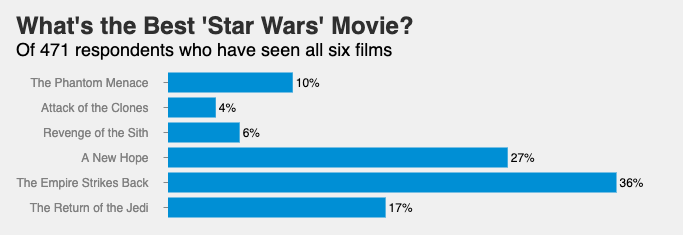

In [18]:
# test your code
genBestVis(sw,episodes)

## Make sure to *style* your visualization to match the original the best you can

We can also drill down and find out, generally, how people rate the films. Overall, fans broke into two camps: those who preferred the original three movies and those who preferred the three prequels. People who said “The Empire Strikes Back” was their favorite were also likely to rate “A New Hope” and “Return of the Jedi” higher as well. Those who rated “The Phantom Menace” as the best film were more likely to rate prequels higher.

This chart shows how often each film was rated in the top third (best or second-best), the middle third (third or fourth) or the bottom third (second-worst or worst). It’s a more nuanced take on the series:

!["Sol1"](/voc/data/how_rate_resized.png)

** Homework note: Click [here](/voc/data/people_rate.png) to see a version of this plot generated in Altair.

### 2.2 How people rate the 'Star Wars' movie? Recreate the above image using altair (10 Points)

In [19]:
# Recreate this image using altair here (10 POINTS)

def genRateVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above

    seen_cols = ['seen_EI', 'seen_EII', 'seen_EIII', 'seen_EIV', 'seen_EV', 'seen_EVI']
    rank_cols = ['rank_EI', 'rank_EII', 'rank_EIII', 'rank_EIV', 'rank_EV', 'rank_EVI']
    
    # create mask to filter dataset so that it only shows respondents that have seen all movies
    seen_all_movies_mask = inpf[seen_cols].notna().all(axis = 1)
    seen_all_movies_df = inpf[seen_all_movies_mask].copy()

    # convert all rank_cols values to integers
    seen_all_movies_df[rank_cols] = seen_all_movies_df[rank_cols].astype('Int64')

    for rank_col in rank_cols:
        category_col = rank_col.replace('rank_', '')
        seen_all_movies_df[category_col] = pd.cut(
            seen_all_movies_df[rank_col],
            bins = [0, 2, 4, 6],
            labels = ['Top third', 'Middle third', 'Bottom third'],
            include_lowest = True
        )

    # filter out unnecessary columns - leave only episode name appreviations, then map to full movie names
    category_rank_df = seen_all_movies_df[names.keys()].reset_index(drop = True)
    category_rank_df.columns = category_rank_df.columns.map(names)

    # summarize category_rank_df with percentage of values in each cell, rename column indexing, then make long-form summarization for visualization
    vis_summary = category_rank_df.apply(lambda x: x.value_counts(normalize = True))
    vis_summary = vis_summary.reset_index().rename(columns = {'index': 'Category'})
    vis_summary = vis_summary.melt(id_vars = 'Category', var_name = 'Movie', value_name = 'Percentage')

    # setup base chart with x, y, and color encodings
    base = alt.Chart(vis_summary).encode(
        x = alt.X('Percentage:Q', axis = None),
        y = alt.Y('Movie:N', sort = names_l, axis = alt.Axis(title = None, domain = False, labelColor = 'grey', labelFontSize = 12, labelPadding = 15)),
        color = alt.Color('Category:O', 
                    scale = alt.Scale(
                        domain = ['Top third', 'Middle third', 'Bottom third'], 
                        range = ['#4da74a', '#2596be', '#ff2600']
                    ), 
                    legend = None
                )
    )

    # add bars to base encodings
    bars = base.mark_bar(size = 20)

    # add text to base encodings with each percentage next to the associated bar
    text = bars.mark_text(
        align = 'left',
        dx = 5,
        fontSize = 12,
    ).encode(
        text = alt.Text('Percentage:Q', format = '.0%')
    )

    # resize chart to match example
    sizing = (bars + text).properties(
        width = 100,
        height = 150
    )

    # add faceting to chart to separate thirds, then format chart title and view
    chart = sizing.facet(
        column = alt.Column('Category:O', 
                            sort = ['Top third', 'Middle third', 'Bottom third'], 
                            header = alt.Header(title = None, labelFontWeight = 'bold', labelFontSize = 12)
        ),
        spacing = 20,
        title = {
            'text': "How People Rate the 'Star Wars' Movies",
            'fontSize': 28,
            'fontWeight': 'bold',
            'color': '#2F2F2F',
            'subtitle': [f'How often each film was rated in the top, middle, and bottom third', 
                         f'(by {seen_all_movies_df.shape[0]} respondents who have seen all six films)'],
            'subtitleFontSize': 14,
            'anchor': 'start',
            'offset': 20
        }
    ).configure(
        background = '#F0F0F0',
        padding = 15
    ).configure_view(
        stroke = None
    )
    
    return chart

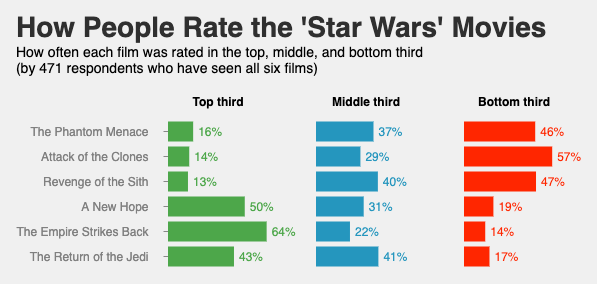

In [20]:
# let's check our solution
genRateVis(sw,episodes)

Finally, we took a boilerplate format used by political favorability polls — “Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her” — and asked respondents to rate characters in the series.

!["Sol1"](/voc/data/char_ranking_resized.png)


** Homework note. Here's an example solution generated in Altair:
!["Sol1"](/voc/data/people_rate_s.png)

Be careful here in what you're dividing by to get the totals for each character.

### 2.3 Star Wars' Characters Favorability Ratings. Recreate the above image using altair (10 Points)

In [21]:
# Recreate this image using altair here (10 POINTS)

def genFavorabilityVis(inpf):
    # input: inpf, the star wars dataset (as defined at top of file)
    # output: the Altair visualization as described above

    characters = ['Han Solo', 'Luke Skywalker', 'Princess Leia Organa', 'Anakin Skywalker',
                  'Obi Wan Kenobi', 'Emperor Palpatine', 'Darth Vader', 'Lando Calrissian', 
                  'Boba Fett', 'C-3P0', 'R2 D2', 'Jar Jar Binks', 'Padme Amidala', 'Yoda']

    bins = {'Very favorably': 'Favorable', 'Somewhat favorably': 'Favorable',
            'Neither favorably nor unfavorably (neutral)': 'Neutral',
            'Somewhat unfavorably': 'Unfavorable', 'Very unfavorably': 'Unfavorable',
            'Unfamiliar (N/A)': 'Unfamiliar'}

    # create mask to filter dataset so that it only shows respondents that have seen all movies
    rated_all_characters_mask = inpf[characters].notna().any(axis = 1)
    rated_all_characters_df = inpf[rated_all_characters_mask].copy()

    favorability_summary = rated_all_characters_df[characters].apply(lambda x: x.value_counts(normalize = True)).T
    
    # rename the columns, then bin the same column names
    favorability_summary.columns = favorability_summary.columns.map(bins)
    favorability_summary = favorability_summary.groupby(level = 0, axis = 1).sum()

    # melt columns into long-form dataset
    favorability_summary = favorability_summary.reset_index().rename(columns = {'index': 'Character'})
    favorability_summary = favorability_summary.melt(id_vars = 'Character', var_name = 'Favorability', value_name = 'Percentage')

    # get order of rows by most to least favorable characters
    character_order = favorability_summary[favorability_summary['Favorability'] == 'Favorable'].sort_values('Percentage', ascending = False)['Character'].tolist()
    
    base = alt.Chart(favorability_summary).mark_bar(size = 20).encode(
        x = alt.X('Percentage:Q', axis = None),
        y = alt.Y('Character:N', 
                    sort = character_order, 
                    axis = alt.Axis(
                        title = None, domain = False, labelColor = 'grey', labelFontSize = 12, labelPadding = 15)),
        color = alt.Color('Favorability:O',
                    scale = alt.Scale(
                        domain = ['Favorable', 'Neutral', 'Unfavorable', 'Unfamiliar'], 
                        range = ['#77ab43', '#008fd5', '#ff2700', '#999999']
                    ), 
                    legend = None)
    )

    text = base.mark_text(
        align = 'left',
        dx = 5,
        fontSize = 12,
    ).encode(
        text = alt.Text('Percentage:Q', format = '.0%')
    )

    chart = (base + text).properties(
        width = 100,
        height = 350
    ).facet(
        column = alt.Column('Favorability:O', 
                            sort = ['Favorable', 'Neutral', 'Unfavorable', 'Unfamiliar'], 
                            header = alt.Header(title = None, labelFontWeight = 'bold', labelFontSize = 12)
        ),
        spacing = 20,
        title = {
            'text': "'Star Wars' Character Favorability Ratings",
            'fontSize': 28,
            'fontWeight': 'bold',
            'color': '#2F2F2F',
            'subtitle': f'By {rated_all_characters_df.shape[0]} respondents',
            'subtitleFontSize': 14,
            'anchor': 'start',
            'offset': 10
        }
    ).configure(
        background = '#F0F0F0',
        padding = 15
    ).configure_view(
        stroke = None
    )
    
    return chart

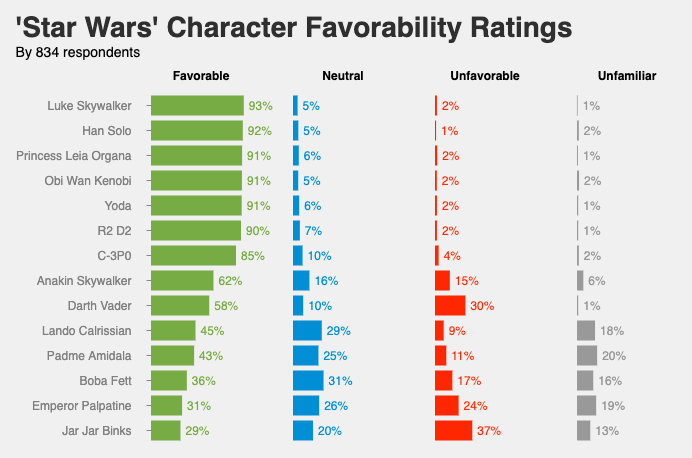

In [22]:
# let's test the solution
genFavorabilityVis(sw)

!["Sol1"](/voc/data/shot_first_article_resized.png)


** Homework note: Click [here](/voc/data/shot_first.png) to see a version of this plot generated in Altair. You may find that you don't get 834 rows (as 538 did) but the percents should still work.

### 2.4 Who shot first? Recreate the above image using altair (10 Points)

In [23]:
# Recreate this image using altair here (10 POINTS)

def genFirstShotVis(inpf):
    # input: inpf, the star wars dataset
    # output: the Altair visualization as described above

    who_shot_first = inpf[inpf['Which character shot first?'].notna()]
    
    who_shot_first_df = inpf['Which character shot first?'].value_counts(normalize = True).reset_index().rename(
                            columns = {'index': 'Answer', 'Which character shot first?': 'Percentage'})

    bars = alt.Chart(who_shot_first_df).mark_bar(size = 25, color = '#008fd5').encode(
        x = alt.X('Percentage:Q', axis = None),
        y = alt.Y('Answer:N', 
                sort = ['Han', 'Greedo', "I don't understand this question"],
                axis = alt.Axis(title = None, domain = False, labelColor = 'grey', labelFontSize = 12, labelPadding = 15))
    )

    text = bars.mark_text(
        align = 'left',
        dx = 5,
        fontSize = 12,
    ).encode(
        text = alt.Text('Percentage:Q', format = '.0%')
    )

    chart = (bars + text).properties(
        width = 500,
        height = 125,
        title = {
            'text': "Who shot first?",
            'fontSize': 24,
            'fontWeight': 'bold',
            'color': '#2F2F2F',
            'subtitle': f"According to {who_shot_first.shape[0]} respondents",
            'subtitleFontSize': 18,
            'anchor': 'start',
            'offset': 10
        }
    ).configure(
        background = '#F0F0F0',
        padding = 15
    ).configure_view(
        stroke = None
    )
    
    return chart

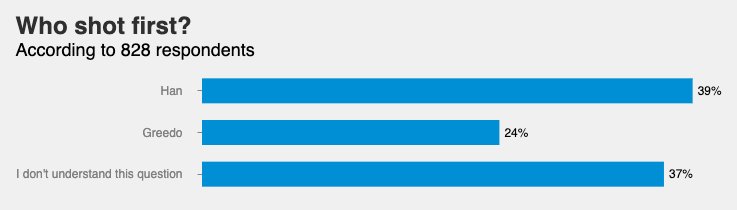

In [24]:
# test our solution
genFirstShotVis(sw)

### 2.5 Make your own (35 points total - 20 for implementation, 15 for justification)

Reading through the article, identify some aspect of the story that would benefit from an extra visualization (you can imagine extending the article if it helps). We would like for you to create two versions of this hypothetical visualization.  You should be able to convincingly argue that one visualization is better than the other.

Note: The two visualizations should use different marks and at least some of the encodings should be different. If you're struggling with coming up with two really different representations, your visualization may simply be too simple. Try to add additional columns/comparisons. 

In [25]:
def prep_trilogy_by_age_data(inpf):

    seen_cols = ['seen_EI', 'seen_EII', 'seen_EIII', 'seen_EIV', 'seen_EV', 'seen_EVI']
    rank_cols = ['rank_EI', 'rank_EII', 'rank_EIII', 'rank_EIV', 'rank_EV', 'rank_EVI']
    
    # create mask to filter dataset so that it only shows respondents that have seen & ranked all movies
    seen_all_movies = inpf[seen_cols].notna().all(axis = 1)
    rank_all_movies = inpf[rank_cols].notna().all(axis = 1)
    df = inpf[seen_all_movies & rank_all_movies].copy()
    
    # drop unused columns
    df = df[rank_cols + ['Age']]

    # convert all rank_cols values to integers
    df[rank_cols] = df[rank_cols].astype('Int64')

    # get average trilogy ratings each respondent
    df['prequel_avg'] = df[['rank_EI', 'rank_EII', 'rank_EIII']].mean(axis = 1).round(2)
    df['original_avg'] = df[['rank_EIV', 'rank_EV', 'rank_EVI']].mean(axis = 1).round(2)

    # get which trilogy ranked higher by each respondent
    df['Best Trilogy'] = np.where(df['prequel_avg'] < df['original_avg'], 'Prequel Trilogy', 'Original Trilogy')

    # summarize data by age
    summary = df.groupby("Age")['Best Trilogy'].value_counts(normalize = True).reset_index(name = 'Percentage')
    
    return summary

prep_trilogy_by_age_data(sw)

,Age,Best Trilogy,Percentage
0,18-29,Original Trilogy,0.775194
1,18-29,Prequel Trilogy,0.224806
2,30-44,Original Trilogy,0.907143
3,30-44,Prequel Trilogy,0.092857
4,45-60,Original Trilogy,0.826446
5,45-60,Prequel Trilogy,0.173554
6,> 60,Original Trilogy,0.625000
7,> 60,Prequel Trilogy,0.375000


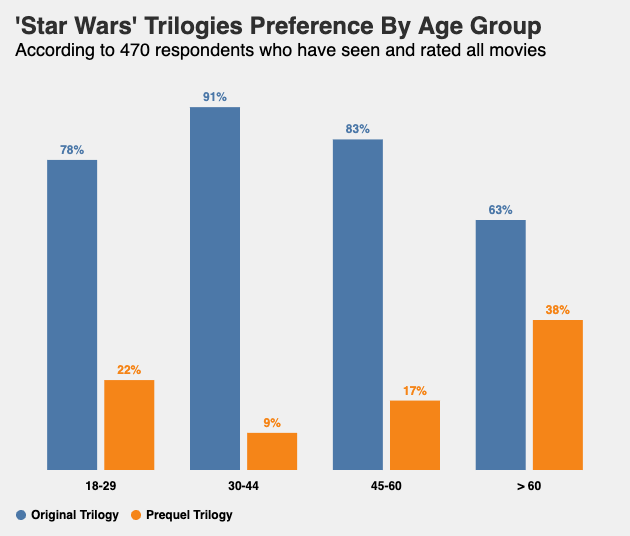

In [26]:
def vis_1(indf):
    
    bars = alt.Chart(prep_trilogy_by_age_data(indf)).mark_bar(size = 50).encode(
        x = alt.X('Age:O', 
                axis = alt.Axis(title = None, domain = False, ticks = False, 
                                labelAngle = 0, labelFontSize = 12, labelFontWeight = 'bold', labelPadding = 10)),
        xOffset = alt.XOffset('Best Trilogy:N'),
        y = alt.Y('Percentage:Q', axis = None),
        color = alt.Color('Best Trilogy:N',
                legend = alt.Legend(direction = 'horizontal', orient = 'bottom', title = None, labelFontSize = 12, labelFontWeight = 'bold'))
    )

    text = bars.mark_text(
        fontSize = 12,
        dy = -10,
        fontWeight = 'bold'
    ).encode(
        text = alt.Text('Percentage:Q', format = '.0%')
    )

    chart = (bars + text).properties(
        width = 600,
        height = 400,
        title = {
            'text': "'Star Wars' Trilogies Preference By Age Group",
            'fontSize': 24,
            'fontWeight': 'bold',
            'color': '#2F2F2F',
            'subtitle': "According to 470 respondents who have seen and rated all movies",
            'subtitleFontSize': 18,
            'anchor': 'start',
            'offset': 10
        }
    ).configure(
        background = '#F0F0F0',
        padding = 15
    ).configure_view(
        stroke = None
    )
    
    return chart

vis_1(sw)

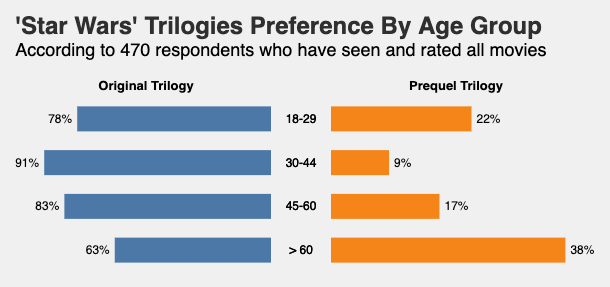

In [46]:
def vis_2(indf):

    base = alt.Chart(prep_trilogy_by_age_data(indf)).properties(
        height = 175
    )

    color_scale = alt.Scale(domain = ['Original Trilogy', 'Prequel Trilogy'],
                            range = ['#4c78a8', '#f58518'])
    
    left = base.transform_filter(
        alt.datum['Best Trilogy'] == 'Original Trilogy'
    ).mark_bar(size = 25).encode(
        alt.Y('Age:O').axis(None),
        alt.X('Percentage:Q').title(None).sort('descending').axis(None),
        alt.Color('Best Trilogy:N').scale(color_scale).legend(None)
    ).properties(title = 'Original Trilogy', width = 250)

    left_text = base.transform_filter(
        alt.datum['Best Trilogy'] == 'Original Trilogy'
    ).mark_text(
        fontSize = 12, align = 'right', dx = -5
    ).encode(
        alt.Y('Age:O').axis(None),
        alt.X('Percentage:Q'),
        alt.Text('Percentage:Q', format = '.0%')
    )
    
    middle = base.mark_text(
        fontSize = 12
    ).encode(
        alt.Y('Age:O').axis(None),
        alt.Text('Age:O')
    ).properties(width = 50)

    right = base.transform_filter(
        alt.datum['Best Trilogy'] == 'Prequel Trilogy'
    ).mark_bar(size = 25).encode(
        alt.Y('Age:O').axis(None),
        alt.X('Percentage:Q').title(None).axis(None),
        alt.Color('Best Trilogy:N').scale(color_scale).legend(None)
    ).properties(title = 'Prequel Trilogy', width = 250)

    right_text = base.transform_filter(
        alt.datum['Best Trilogy'] == 'Prequel Trilogy'
    ).mark_text(
        fontSize = 12, align = 'left', dx = 5
    ).encode(
        alt.Y('Age:O').axis(None),
        alt.X('Percentage:Q'),
        alt.Text('Percentage:Q', format = '.0%')
    )
    
    chart = alt.concat(
        (left + left_text), middle, (right + right_text), spacing = 5
    ).properties(
        title = {
            'text': "'Star Wars' Trilogies Preference By Age Group",
            'fontSize': 24,
            'fontWeight': 'bold',
            'color': '#2F2F2F',
            'subtitle': "According to 470 respondents who have seen and rated all movies",
            'subtitleFontSize': 18,
            'anchor': 'start',
            'offset': 20
        }
    ).configure(
        background = '#F0F0F0',
        padding = 15
    ).configure_view(
        stroke = None
    )
    
    return chart

vis_2(sw)

#### Justification
*Provide your justification here* to argue why your "better" version is actually better. Make sure to defend this based on expressiveness and effectiveness as well as perceptual arguments.

I implemented a grouped bar chart and a diverging bar chart to visualize the preference in Star Wars trilogies by age group represented in the survey. The **grouped bar chart** is better because it correctely emphasizes comparison within age groups (between trilogies) rather than across age groups. The side-by-side positioning with a common baseline makes the preference gap immediately clear - you can instantly see that 18-29 year olds show a meaningful, but not overwhelming 78% vs. 22% preference for the original trilogy, whereas 30-44 year-olds show a near-unanimous 91% vs. 9% preference for the original trilogy. This reveals that younger fans who likely grew up with the prequels are more divided. 

The diverging bar chart fails at this primary objective because each side uses its own scale, making bars look deceptively similar in size even when representing very different percentages (78% looks fairly similar to 91% when scaled separately). This forces the viewer to read the text labels rather than relaying on visual perception.

From an expressiveness standpoint, the grouped chart better represents the data structure where preferences are grouped together within each age group, matching how we conceptually understand comparing two options within a group.

From an effectiveness standpoint, the grouped chart optimizes the primary task of comparing trilogy preferences within each age group, allowing for making immediate judgements without needing text labels to guide the visualization.